In [1]:
!pip install open-clip-torch
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import open_clip

from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Đường dẫn  liệu
DATASET_PATH = "/content/drive/MyDrive/BRACoL"
IMAGE_DIR    = "/content/drive/MyDrive/coffee-datasets/coffee-datasets/leaf/images" # Đường dẫn folder chứa tệp .jpg
LABEL_FILE   = "/content/drive/MyDrive/coffee-datasets/coffee-datasets/leaf/dataset.csv"

SEVERITY_CLASSES = ['Very Low', 'Low', 'High', 'Very High']
NUM_CLASSES      = 4  # Chỉ còn 4 mức độ bệnh

CLIP_MODEL   = "ViT-B-32"
PRETRAINED   = "openai"
IMAGE_SIZE   = 224

BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-4


TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
SEED         = 42

SAVE_PATH    = "/content/drive/MyDrive/clip_severity_2b_best.pt"

torch.manual_seed(SEED)
np.random.seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

print(f"Số lượng lớp dự đoán: {NUM_CLASSES} (Mức độ nghiêm trọng)")

Số lượng lớp dự đoán: 4 (Mức độ nghiêm trọng)


In [5]:
class CoffeeDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples   = samples
        self.augment   = augment
        self.normalize = transforms.Normalize(
            mean=(0.48145466, 0.4578275,  0.40821073),
            std =(0.26862954, 0.26130258, 0.27577711),
        )
        self.base_transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
        ])
        self.aug_transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.augment:
            image = self.aug_transform(image)
        else:
            image = self.base_transform(image)
        image = self.normalize(image)
        return image, label

In [10]:
# df_labels là dataframe chứa file csv của bạn
class_counts = df_labels['severity'].value_counts().sort_index()

print("Thống kê số lượng mẫu từng class (Severity):")
for idx, count in class_counts.items():
    print(f"Mức {idx} ({SEVERITY_CLASSES[idx]}): {count} mẫu")

Thống kê số lượng mẫu từng class (Severity):
Mức 0 (Very Low): 966 mẫu
Mức 1 (Low): 345 mẫu
Mức 2 (High): 106 mẫu
Mức 3 (Very High): 56 mẫu


In [9]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

SEED = 42
df_labels = pd.read_csv(LABEL_FILE)
# Lọc: chỉ giữ lại ảnh có bệnh (severity > 0)
df_labels = df_labels[df_labels['severity'] > 0].copy()
# Chuyển nhãn từ 1-4 thành 0-3
df_labels['severity'] = df_labels['severity'] - 1

# Các phần split train/val/test phía sau giữ nguyên,
# nhưng nhớ dùng cột 'severity' đã được map lại.

train_df, temp_df = train_test_split(
    df_labels, test_size=0.3, stratify=df_labels['severity'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['severity'], random_state=SEED
)

def get_path(img_id):
    return os.path.join(IMAGE_DIR, f"{int(img_id)}.jpg")

train_samples = list(zip(train_df['id'].apply(get_path), train_df['severity']))
val_samples   = list(zip(val_df['id'].apply(get_path), val_df['severity']))
test_samples  = list(zip(test_df['id'].apply(get_path), test_df['severity']))

print(f"Train={len(train_samples)}, Val={len(val_samples)}, Test={len(test_samples)}")

Train=1031, Val=221, Test=221


In [11]:
train_loader = DataLoader(
    CoffeeDataset(train_samples, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    CoffeeDataset(val_samples, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    CoffeeDataset(test_samples, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [12]:
class CLIPClassifier(nn.Module):
    def __init__(self, unfreeze_last_n=4):
        super().__init__()
        clip_model, _, _ = open_clip.create_model_and_transforms(
            CLIP_MODEL, pretrained=PRETRAINED)
        self.visual_encoder = clip_model.visual

        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        for block in self.visual_encoder.transformer.resblocks[-unfreeze_last_n:]:
            for param in block.parameters():
                param.requires_grad = True

        self.classifier = nn.Sequential(
            nn.LayerNorm(512),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES),
        )

    def forward(self, x):
        features = self.visual_encoder(x)
        return self.classifier(features)

In [14]:
model = CLIPClassifier(unfreeze_last_n=4).to(DEVICE)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [15]:
class_counts_tn2c = torch.tensor([924, 332, 101, 56], dtype=torch.float32)
pos_weights = (class_counts_tn2c.sum() - class_counts_tn2c) / class_counts_tn2c
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(DEVICE))

backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        # Visual Encoder của CLIP ViT-B-32
        if "visual_encoder" in name:
            backbone_params.append(param)
        else:
            head_params.append(param)

# 4. Thiết lập Optimizer với Discriminative Learning Rate
# Giữ nguyên tỷ lệ 1:10 (1e-5 và 1e-4) để bảo tồn tri thức từ CLIP
optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params, 'lr': 1e-4}
], weight_decay=WEIGHT_DECAY)

# 5. Scheduler (Giữ nguyên để đảm bảo hội tụ mịn)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6)

In [19]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, mean_absolute_error,
                              f1_score, cohen_kappa_score)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_mae": [], "val_obo": []}
best_val_mae = float('inf')

for epoch in range(1, EPOCHS + 1):
    # --- PHASE: TRAIN ---
    model.train()
    train_loss = train_correct = train_total = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # CHỈNH SỬA 1: Tạo nhãn Ordinal (ví dụ mức 2 -> [1, 1, 1, 0])
        # labels lúc này đã được map về 0-3 từ Cell trước
        labels_ord = torch.zeros(labels.size(0), NUM_CLASSES).to(DEVICE)
        for i in range(labels.size(0)):
            labels_ord[i, :labels[i] + 1] = 1

        optimizer.zero_grad()
        outputs = model(images)

        # Sử dụng nhãn Ordinal cho hàm BCE
        loss = criterion(outputs, labels_ord)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        # CHỈNH SỬA 2: Dự đoán dựa trên ngưỡng 0.5 (Tích lũy bậc thang)
        # logit > 0 tương đương với sigmoid > 0.5
        preds = (outputs > 0).int().sum(dim=1) - 1
        preds = torch.clamp(preds, min=0) # Đảm bảo không bị âm

        train_correct += (preds == labels).sum().item()
        train_total += images.size(0)

    # --- PHASE: EVAL ---
    model.eval()
    val_loss = val_correct = val_total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            # Tạo nhãn Ordinal cho validation để tính loss đồng nhất
            labels_ord = torch.zeros(labels.size(0), NUM_CLASSES).to(DEVICE)
            for i in range(labels.size(0)):
                labels_ord[i, :labels[i] + 1] = 1

            outputs = model(images)
            val_loss += criterion(outputs, labels_ord).item() * images.size(0)

            # Dự đoán trong pha Eval
            preds = (outputs > 0).int().sum(dim=1) - 1
            preds = torch.clamp(preds, min=0)

            val_correct += (preds == labels).sum().item()
            val_total += images.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    # Tính toán các chỉ số
    all_preds_np = np.array(all_preds)
    all_labels_np = np.array(all_labels)
    v_mae = mean_absolute_error(all_labels_np, all_preds_np)
    v_obo = (np.abs(all_preds_np - all_labels_np) <= 1).mean()

    t_loss = train_loss / train_total
    t_acc = train_correct / train_total
    v_loss = val_loss / val_total
    v_acc = val_correct / val_total

    scheduler.step()

    # Lưu lịch sử
    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["val_mae"].append(v_mae)
    history["val_obo"].append(v_obo)

    if v_mae < best_val_mae:
        best_val_mae = v_mae
        torch.save({"epoch": epoch, "state_dict": model.state_dict(),
                    "val_mae": v_mae, "val_acc": v_acc}, SAVE_PATH)
        saved = " <- best MAE saved"
    else:
        saved = ""

    print(f"[{epoch:02d}/{EPOCHS}] "
          f"loss: {t_loss:.4f} acc: {t_acc:.4f} | "
          f"val_loss: {v_loss:.4f} val_acc: {v_acc:.4f} MAE: {v_mae:.4f} OBO: {v_obo:.4f}{saved}")

[01/30] loss: 0.5628 acc: 0.6188 | val_loss: 0.5394 val_acc: 0.5430 MAE: 0.6968 OBO: 0.7738 <- best MAE saved
[02/30] loss: 0.3909 acc: 0.6896 | val_loss: 0.5064 val_acc: 0.7014 MAE: 0.3846 OBO: 0.9186 <- best MAE saved
[03/30] loss: 0.4311 acc: 0.6877 | val_loss: 0.6392 val_acc: 0.7285 MAE: 0.2805 OBO: 0.9910 <- best MAE saved
[04/30] loss: 0.2779 acc: 0.7449 | val_loss: 0.4683 val_acc: 0.6471 MAE: 0.3801 OBO: 0.9729
[05/30] loss: 0.3351 acc: 0.7498 | val_loss: 0.5440 val_acc: 0.7557 MAE: 0.2579 OBO: 0.9864 <- best MAE saved
[06/30] loss: 0.2374 acc: 0.7837 | val_loss: 0.4638 val_acc: 0.7149 MAE: 0.3258 OBO: 0.9593
[07/30] loss: 0.1986 acc: 0.8147 | val_loss: 0.5302 val_acc: 0.6697 MAE: 0.3529 OBO: 0.9774
[08/30] loss: 0.2148 acc: 0.8147 | val_loss: 0.7823 val_acc: 0.7647 MAE: 0.2534 OBO: 0.9819 <- best MAE saved
[09/30] loss: 0.1727 acc: 0.8487 | val_loss: 0.7522 val_acc: 0.7376 MAE: 0.2670 OBO: 0.9955
[10/30] loss: 0.1610 acc: 0.8448 | val_loss: 0.9823 val_acc: 0.7964 MAE: 0.2217 OB

In [21]:
print(f"Số lượng mẫu tập Train: {len(train_samples)}")
print(f"Số lượng mẫu tập Val: {len(val_samples)}")
print(f"Số lượng mẫu tập Test: {len(test_samples)}")

# Thử lấy 1 batch từ val_loader để xem có chạy được không
try:
    data_iter = iter(val_loader)
    images, labels = next(data_iter)
    print(f"Batch đầu tiên của Val OK: {images.shape}, {labels.shape}")
except StopIteration:
    print("LỖI CỰC NẶNG: val_loader không có dữ liệu!")
except Exception as e:
    print(f"Lỗi khác khi load data: {e}")

Số lượng mẫu tập Train: 1031
Số lượng mẫu tập Val: 221
Số lượng mẫu tập Test: 221
Batch đầu tiên của Val OK: torch.Size([32, 3, 224, 224]), torch.Size([32])


In [ ]:
for name, _ in model.named_parameters():
    print(name)

visual_encoder.class_embedding
visual_encoder.positional_embedding
visual_encoder.proj
visual_encoder.conv1.weight
visual_encoder.ln_pre.weight
visual_encoder.ln_pre.bias
visual_encoder.transformer.resblocks.0.ln_1.weight
visual_encoder.transformer.resblocks.0.ln_1.bias
visual_encoder.transformer.resblocks.0.attn.in_proj_weight
visual_encoder.transformer.resblocks.0.attn.in_proj_bias
visual_encoder.transformer.resblocks.0.attn.out_proj.weight
visual_encoder.transformer.resblocks.0.attn.out_proj.bias
visual_encoder.transformer.resblocks.0.ln_2.weight
visual_encoder.transformer.resblocks.0.ln_2.bias
visual_encoder.transformer.resblocks.0.mlp.c_fc.weight
visual_encoder.transformer.resblocks.0.mlp.c_fc.bias
visual_encoder.transformer.resblocks.0.mlp.c_proj.weight
visual_encoder.transformer.resblocks.0.mlp.c_proj.bias
visual_encoder.transformer.resblocks.1.ln_1.weight
visual_encoder.transformer.resblocks.1.ln_1.bias
visual_encoder.transformer.resblocks.1.attn.in_proj_weight
visual_encoder.t

In [20]:
# ── Cell 11: Evaluate on Test Set (Sửa cho TN2c - Ordinal BCE) ──────
import numpy as np
import torch

# 1. Load best checkpoint (Đảm bảo SAVE_PATH trỏ tới file của TN2c)
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

test_preds, test_labels = [], []

# 2. Inference trên Test set
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        # --- SỬA LOGIC DỰ ĐOÁN CHO ORDINAL ---
        # Tính tổng các nút có sigmoid > 0.5 (tương đương logit > 0)
        preds = (outputs > 0).int().sum(dim=1) - 1
        preds = torch.clamp(preds, min=0).cpu().numpy()

        test_preds.extend(preds)
        test_labels.extend(labels.numpy())

test_preds  = np.array(test_preds)
test_labels = np.array(test_labels)

# 3. Metrics
acc     = accuracy_score(test_labels, test_preds)
mae     = mean_absolute_error(test_labels, test_preds)
macro_f1= f1_score(test_labels, test_preds, average='macro', zero_division=0)
kappa   = cohen_kappa_score(test_labels, test_preds, weights='quadratic')

# Off-by-one accuracy: chấp nhận sai tối đa 1 bậc
obo_acc = float((np.abs(test_preds - test_labels) <= 1).mean())

# Per-class accuracy
print("=" * 52)
print("   KẾT QUẢ TRÊN TẬP TEST — TN2c (Severity Ordinal BCE)   ")
print("=" * 52)
print(f"  Accuracy        : {acc:.4f}")
print(f"  Macro F1        : {macro_f1:.4f}")
print(f"  MAE             : {mae:.4f}  ← Chỉ số quan trọng nhất của Ordinal")
print(f"  Off-by-1 Acc    : {obo_acc:.4f}")
print(f"  Quadratic Kappa : {kappa:.4f}")
print("-" * 52)

print("\nClassification Report:")
print(classification_report(
    test_labels, test_preds,
    target_names=SEVERITY_CLASSES, # Lúc này là 4 lớp: Very Low -> Very High
    digits=4, zero_division=0
))

# Phân phối prediction vs ground truth
print("Phân phối prediction vs ground truth:")
print(f"  {'Class':<12} {'GT':>6} {'Pred':>6}")
print(f"  {'-'*26}")
from collections import Counter
gt_cnt   = Counter(test_labels)
pred_cnt = Counter(test_preds)
for i, name in enumerate(SEVERITY_CLASSES):
    gt   = gt_cnt.get(i, 0)
    pred = pred_cnt.get(i, 0)
    print(f"  {name:<12} {gt:>6} {pred:>6}")

   KẾT QUẢ TRÊN TẬP TEST — TN2c (Severity Ordinal BCE)   
  Accuracy        : 0.8371
  Macro F1        : 0.7014
  MAE             : 0.1629  ← Chỉ số quan trọng nhất của Ordinal
  Off-by-1 Acc    : 1.0000
  Quadratic Kappa : 0.8697
----------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

    Very Low     0.8968    0.9586    0.9267       145
         Low     0.7333    0.6346    0.6804        52
        High     0.6000    0.3750    0.4615        16
   Very High     0.6364    0.8750    0.7368         8

    accuracy                         0.8371       221
   macro avg     0.7166    0.7108    0.7014       221
weighted avg     0.8274    0.8371    0.8282       221

Phân phối prediction vs ground truth:
  Class            GT   Pred
  --------------------------
  Very Low        145    155
  Low              52     45
  High             16     10
  Very High         8     11


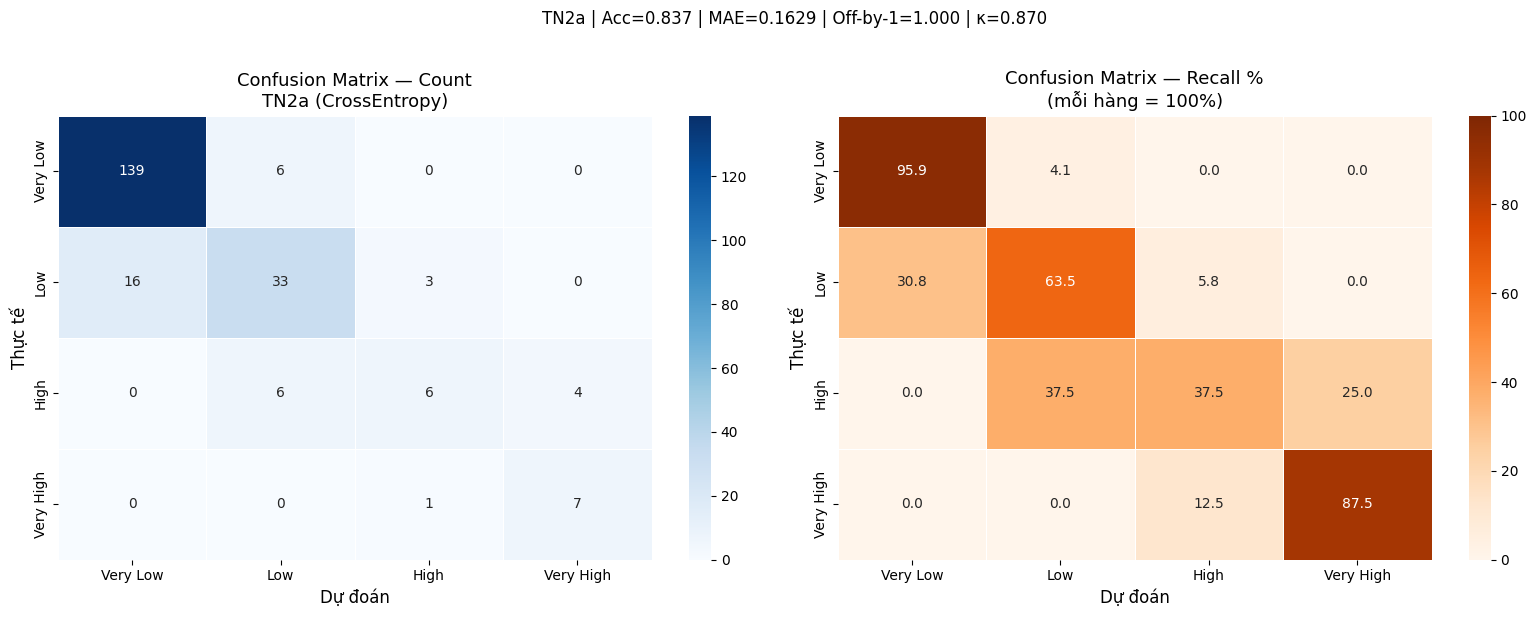


Phân tích hướng nhầm lẫn:
  Predict THẤP hơn thực tế (under):   23 mẫu  ← nguy hiểm: bệnh nặng bị đánh giá nhẹ
  Predict ĐÚNG                     :  185 mẫu
  Predict CAO hơn thực tế (over)   :   13 mẫu

Recall từng mức severity:
  Very Low  :  95.9%  (6/145 sai)  
  Low       :  63.5%  (19/52 sai)  
  High      :  37.5%  (10/16 sai)  ← cần cải thiện
  Very High :  87.5%  (1/8 sai)  


In [22]:
# ── Cell 12: Confusion Matrix + Error Analysis ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Confusion matrix (count) ─────────────────────────────
cm = confusion_matrix(test_labels, test_preds,
                      labels=list(range(len(SEVERITY_CLASSES))))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=SEVERITY_CLASSES,
            yticklabels=SEVERITY_CLASSES,
            linewidths=0.5)
axes[0].set_xlabel('Dự đoán',  fontsize=12)
axes[0].set_ylabel('Thực tế',  fontsize=12)
axes[0].set_title('Confusion Matrix — Count\nTN2a (CrossEntropy)', fontsize=13)

# ── Plot 2: Confusion matrix (% theo hàng = recall từng class) ───
cm_norm = cm.astype(float)
row_sum = cm_norm.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1           # tránh chia 0
cm_norm = cm_norm / row_sum * 100   # % recall

sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=SEVERITY_CLASSES,
            yticklabels=SEVERITY_CLASSES,
            linewidths=0.5,
            vmin=0, vmax=100)
axes[1].set_xlabel('Dự đoán',  fontsize=12)
axes[1].set_ylabel('Thực tế',  fontsize=12)
axes[1].set_title('Confusion Matrix — Recall %\n(mỗi hàng = 100%)', fontsize=13)

plt.suptitle(
    f'TN2a | Acc={acc:.3f} | MAE={mae:.4f} | Off-by-1={obo_acc:.3f} | κ={kappa:.3f}',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('cm_TN2a.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Phân tích lỗi theo hướng ─────────────────────────────────────
print("\nPhân tích hướng nhầm lẫn:")
errors = test_preds - test_labels           # âm = predict thấp hơn thực tế
print(f"  Predict THẤP hơn thực tế (under): {(errors < 0).sum():>4} mẫu  "
      f"← nguy hiểm: bệnh nặng bị đánh giá nhẹ")
print(f"  Predict ĐÚNG                     : {(errors == 0).sum():>4} mẫu")
print(f"  Predict CAO hơn thực tế (over)   : {(errors > 0).sum():>4} mẫu")

# Severity cao nhất bị nhầm nhiều nhất
print("\nRecall từng mức severity:")
for i, name in enumerate(SEVERITY_CLASSES):
    mask    = test_labels == i
    if mask.sum() == 0:
        continue
    recall  = (test_preds[mask] == i).mean()
    n_total = mask.sum()
    n_wrong = (test_preds[mask] != i).sum()
    print(f"  {name:<10}: {recall*100:5.1f}%  "
          f"({n_wrong}/{n_total} sai)  "
          f"{'← cần cải thiện' if recall < 0.5 else ''}")

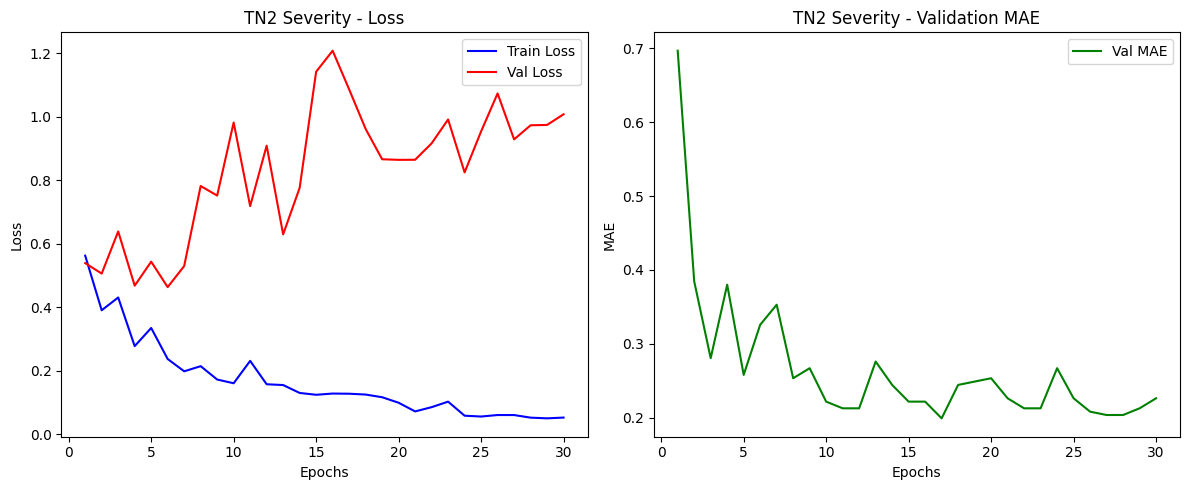

In [24]:
import matplotlib.pyplot as plt

def plot_history(history, title="Training History"):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Vẽ biểu đồ Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r', label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Vẽ biểu đồ MAE
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_mae'], 'g', label='Val MAE')
    plt.title(f'{title} - Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Gọi hàm để vẽ
plot_history(history, title="TN2 Severity")

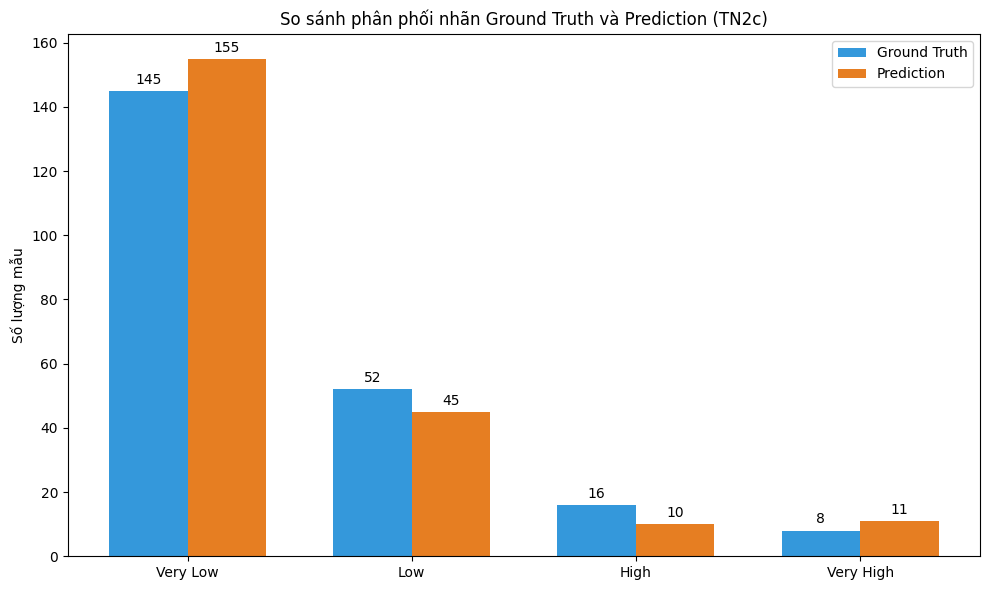

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Chuẩn bị dữ liệu từ kết quả bạn vừa chạy
classes = SEVERITY_CLASSES
gt_values = [gt_cnt.get(i, 0) for i in range(len(classes))]
pred_values = [pred_cnt.get(i, 0) for i in range(len(classes))]

x = np.arange(len(classes))
width = 0.35

# 2. Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, gt_values, width, label='Ground Truth', color='#3498db')
rects2 = ax.bar(x + width/2, pred_values, width, label='Prediction', color='#e67e22')

# Thêm nhãn và tùy chỉnh
ax.set_ylabel('Số lượng mẫu')
ax.set_title('So sánh phân phối nhãn Ground Truth và Prediction (TN2c)')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

# Gắn số lượng lên đầu mỗi cột
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.savefig('distribution_TN2c.png', dpi=300) # Lưu lại để đưa vào luận văn
plt.show()